In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import DeconV as dv

In [2]:
true_proportions = pd.read_csv("../../../fimm/data/pbmc/true.csv", sep=",", index_col=0)
true_proportions = true_proportions.sort_index(axis="columns").sort_index(axis="rows")
true_proportions.index.name = None

true_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.082933,0.229503,0.204228,0.012943,0.377872,0.092520
453W_PBMC,0.058854,0.287304,0.320502,0.010775,0.245667,0.076899
4DUY_PBMC,0.105722,0.320983,0.164215,0.009276,0.294850,0.104953
684C_PBMC,0.114487,0.341211,0.177874,0.014584,0.254811,0.097033
925L_PBMC,0.187059,0.231691,0.223318,0.007860,0.234494,0.115577
9JD4_PBMC,0.094967,0.343631,0.269980,0.010984,0.194281,0.086157
CR3L_PBMC,0.137329,0.330611,0.186336,0.016135,0.196571,0.133018
CYFZ_PBMC,0.098471,0.204259,0.327271,0.007765,0.197529,0.164706
CZJE_PBMC,0.148297,0.220536,0.169017,0.018178,0.262195,0.181776
FLWA_PBMC,0.102362,0.289034,0.102056,0.012963,0.255109,0.238477


In [3]:
# deconv_proportions = pd.read_csv("pbmc/nb/proportions_separate_bd.tsv", sep="\t", index_col=0)
# deconv_proportions = deconv_proportions.sort_index(axis="columns").sort_index(axis="rows")
# deconv_proportions

In [4]:
# music_proportions = pd.read_csv("3rd-party/music/pbmc/music_proportions.csv", index_col=0)
# music_proportions.rename(columns={"UNKWN": "unknown"}, inplace=True)
# music_proportions = music_proportions.sort_index(axis="columns").sort_index(axis="rows")
# music_proportions.index.name = None
# music_proportions

In [5]:
scaden_proportions = pd.read_csv("3rd-party/scaden/pbmc/scaden_predictions.txt", sep="\t", index_col=0)
scaden_proportions.index = pd.read_csv("3rd-party/scaden/pbmc/data/pbmc_bulk_data.txt", sep="\t", index_col=0).columns
scaden_proportions = scaden_proportions.sort_index(axis="columns").sort_index(axis="rows")
scaden_proportions

,B cells,CD4 T,CD8 T,DCs,Monocytes,NK
36TS_PBMC,0.003563,0.584270,0.000043,0.001859,0.404459,0.005806
453W_PBMC,0.002674,0.716508,0.000047,0.001362,0.272155,0.007254
4DUY_PBMC,0.003598,0.754414,0.000022,0.000762,0.236190,0.005014
684C_PBMC,0.004595,0.755102,0.000038,0.001187,0.234067,0.005011
925L_PBMC,0.010845,0.737469,0.000055,0.001143,0.244674,0.005813
9JD4_PBMC,0.003480,0.779994,0.000026,0.000683,0.210993,0.004825
CR3L_PBMC,0.006806,0.753481,0.000022,0.001138,0.234121,0.004433
CYFZ_PBMC,0.005520,0.720417,0.000063,0.001399,0.264148,0.008453
CZJE_PBMC,0.009826,0.709413,0.000052,0.002275,0.268739,0.009695
FLWA_PBMC,0.003925,0.701876,0.000045,0.001229,0.285183,0.007741


In [6]:
melt = true_proportions.reset_index().melt(id_vars="index")
melt.rename(columns={"index": "sample", "value": "true", "variable":"cell_type"}, inplace=True)
# melt["deconv"] = deconv_proportions.reset_index().melt(id_vars="index")["value"]
melt["scaden"] = scaden_proportions.reset_index().melt(id_vars="index")["value"]
# melt["music"] = music_proportions.reset_index().melt(id_vars="index")["value"]
melt

,sample,cell_type,true,scaden
0,36TS_PBMC,B cells,0.082933,0.003563
1,453W_PBMC,B cells,0.058854,0.002674
2,4DUY_PBMC,B cells,0.105722,0.003598
3,684C_PBMC,B cells,0.114487,0.004595
4,925L_PBMC,B cells,0.187059,0.010845
...,...,...,...,...
67,CYFZ_PBMC,NK,0.164706,0.008453
68,CZJE_PBMC,NK,0.181776,0.009695
69,FLWA_PBMC,NK,0.238477,0.007741
70,FY2H_PBMC,NK,0.032445,0.007180


In [8]:
def ccc(est, true):
    p = np.corrcoef(est, true)[0,1]
    mu_est = np.mean(est)
    mu_true = np.mean(true)
    s_est = np.std(est)
    s_true = np.std(true)

    return (2.0 * p * s_est * s_true) / (s_est**2 + s_true**2 + (mu_est - mu_true)**2)

# p_deconv = np.corrcoef(melt["true"], melt["deconv"])[0,1]
p_scaden = np.corrcoef(melt["true"], melt["scaden"])[0,1]
# p_music = np.corrcoef(melt["true"], melt["music"])[0,1]

# ccc_deconv = ccc(melt["true"], melt["deconv"])
ccc_scaden = ccc(melt["true"], melt["scaden"])
# ccc_music = ccc(melt["true"], melt["music"])

# print("DeconV: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_deconv, ccc_deconv))
print("SCADEN: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_scaden, ccc_scaden))
# print("MuSiC: Pearson correlation coefficient: {:.3f}, CCC: {:.3f}".format(p_music, ccc_music))

SCADEN: Pearson correlation coefficient: 0.656, CCC: 0.453


In [11]:
df = true_proportions.reset_index().melt(id_vars="index")
df.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
df["type"] = "true"
df["error"] = None
# # df["true"] = true_proportions.reset_index().melt(id_vars="index")["value"]
# df_true = true_proportions.reset_index().melt(id_vars="index")
# df_true.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
# df_true["type"] = "true"
# df = pd.concat([df_est, df_true])

# melt["deconv_error"] = abs(melt["deconv"] - melt["true"])
melt["scaden_error"] = abs(melt["scaden"] - melt["true"])
# melt["music_error"] = abs(melt["music"] - melt["true"])

# temp = melt[["sample", "cell_type", "deconv", "deconv_error"]].rename(columns={"deconv": "proportion", "deconv_error": "error"})
# temp["type"] = "deconv"
# df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "scaden", "scaden_error"]].rename(columns={"scaden": "proportion", "scaden_error": "error"})
temp["type"] = "scaden"
df = pd.concat([df, temp])

# temp = melt[["sample", "cell_type", "music", "music_error"]].rename(columns={"music": "proportion", "music_error": "error"})
# temp["type"] = "music"
# df = pd.concat([df, temp])

df

,sample,cell_type,proportion,type,error
0,36TS_PBMC,B cells,0.082933,true,NaN
1,453W_PBMC,B cells,0.058854,true,NaN
2,4DUY_PBMC,B cells,0.105722,true,NaN
3,684C_PBMC,B cells,0.114487,true,NaN
4,925L_PBMC,B cells,0.187059,true,NaN
...,...,...,...,...,...
67,CYFZ_PBMC,NK,0.008453,scaden,0.156253
68,CZJE_PBMC,NK,0.009695,scaden,0.172081
69,FLWA_PBMC,NK,0.007741,scaden,0.230735
70,FY2H_PBMC,NK,0.007180,scaden,0.025265


In [14]:
((melt["scaden"] - melt["true"])**2).mean()**0.5

0.21067193069076368

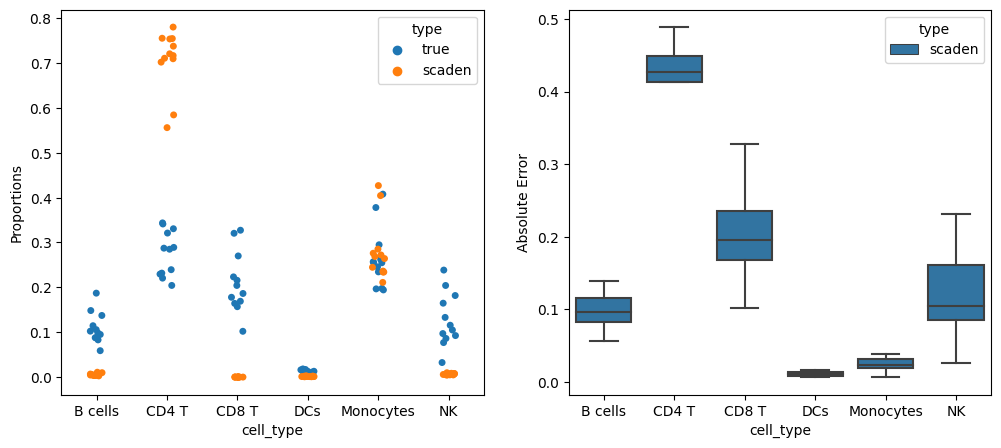

In [12]:
f, ax = plt.subplots(1,2, figsize=(12,5), dpi=100)

sns.stripplot(data=df, x="cell_type", y="proportion", hue="type", ax=ax[0])
# sns.violinplot(data=df, x="cell_type", y="proportion", hue="type", ax=ax[0], showfliers=False, split=True)
sns.boxplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1], showfliers=False)
# sns.swarmplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1])
# sns.violinplot(data=melt, x="cell_type", y="dist", ax=ax[1], showfliers=True)
ax[0].set_ylabel("Proportions")
ax[1].set_ylabel("Absolute Error")
# l = plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

<AxesSubplot: xlabel='type', ylabel='error'>

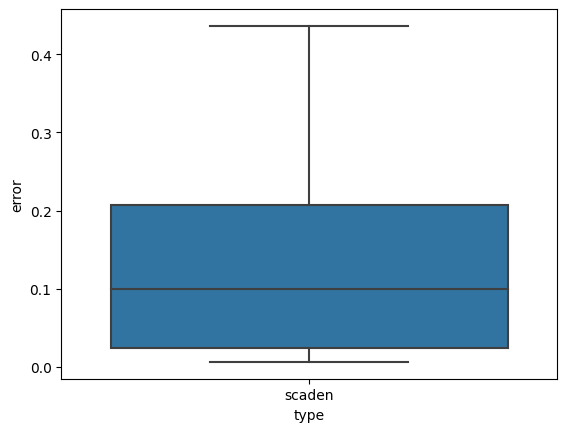

In [13]:
sns.boxplot(data=df[df["type"] != "true"], y="error", x="type", showfliers=False)